# `Breve descrição do problema`

**Integrantes do grupo 3:**

Anysabele de Paula Barbosa Santos

Maria Clara Pereira Gonçalves

Millena Ferreira Marcal das Neves

**Questão 2: Proponha um sistema que tem o objetivo de detectar “fraudes bancárias" supondo que você possui apenas instâncias da classe “não-fraude” para treinar o seu classificador.**

Diante desse cenário, o sistema proposto é um modelo baseado em Inteligência Artificial de One-Class Support Vector Machine. Os dados utilizados são do kaggle e, conforme descrito neste notebook, foram tratados de forma a simular o contexto de apenas instâncias não-fraude no conjunto de treinamento. Demais explicações e resultados estão indicados no notebook.

# `Manipulação de dados`

In [ ]:
# Importação de bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Importação para carregamento do dataset
import gdown

**Carregamento do dataset**

O dataset foi baixado e armazenado no Google Drive, o código faz o carregamento pelo próprio Drive.

Link do dataset original: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud.

In [ ]:
# Puxando o dataset do Google Drive
file_id = "1uX-GWVO25wsK1jxKoQZSSph2tsty1_W1"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "/content/dataset.csv",
    quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1uX-GWVO25wsK1jxKoQZSSph2tsty1_W1
From (redirected): https://drive.google.com/uc?id=1uX-GWVO25wsK1jxKoQZSSph2tsty1_W1&confirm=t&uuid=077798e6-8727-4f39-b29d-f98c1e372982
To: /content/dataset.csv
100%|██████████| 151M/151M [00:02<00:00, 74.4MB/s]


'/content/dataset.csv'

In [ ]:
# Carregamento do dataset
df = pd.read_csv("/content/dataset.csv", sep=",", encoding="latin1")
print("Dataset carregado!")

Dataset carregado!


**Separando as instâncias por classe**

In [ ]:
# Das features existentes, há uma chamada 'Time', de tipo horário
# Será removida por não agregar muita informação
df = df.drop('Time', axis=1)

In [ ]:
# Como o objetivo é criar um modelo treinado apenas por casos fraude, é preciso separar:
df_normal = df[df['Class'] == 0]
df_fraude = df[df['Class'] == 1]

# Verifica que já é um dataset desbalanceado
print(f"Total de transações normais: {len(df_normal)}")
print(f"Total de fraudes: {len(df_fraude)}")

Total de transações normais: 284315
Total de fraudes: 492


In [ ]:
# Contagem de duplicatas, análise só para casos não-fraude
# Remover instâncias da classe minoritária não é benéfico aqui
total_duplicatas = df_normal.duplicated().sum()
print(f"Total de linhas duplicadas: {total_duplicatas}")

df.drop_duplicates(inplace=True)

Total de linhas duplicadas: 9125


In [ ]:
# O dataset é muito extenso, vamos reduzir as intâncias não-fraude
df_normal = df_normal.sample(frac=0.20, random_state=42)

In [ ]:
# Criando os dados de TREINO (apenas com transações normais)
treino_normal, teste_normal = train_test_split(df_normal, test_size=0.2, random_state=42)

# Construindo o conjunto TESTE DEFINITIVO (ambas classes)
df_teste = pd.concat([teste_normal, df_fraude])

In [ ]:
# Baralhando o conjunto de teste para as fraudes não ficarem todas no fim
df_teste = df_teste.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# Separarando as variáveis x do alvo y
# TREINO
X_treino = treino_normal.drop('Class', axis=1)
y_treino = treino_normal['Class']

# TESTE
X_teste = df_teste.drop('Class', axis=1)
y_teste = df_teste['Class']

**Normalização**

In [ ]:
# Há outliers então o RobustScaler foi escolhido
scaler = RobustScaler()

In [ ]:
# Aplicação do scaling
X_treino_tratado = scaler.fit_transform(X_treino)
X_teste_tratado = scaler.transform(X_teste)

In [ ]:
print("\n Resumo do fatiamento")
print(f"Tamanho de X_treino: só normais: {X_treino_tratado.shape}")
print(f"Tamanho de X_teste: misturado: {X_teste_tratado.shape}")


 Resumo do fatiamento
Tamanho de X_treino: só normais: (45490, 29)
Tamanho de X_teste: misturado: (11865, 29)


# `Treinamento do modelo`

Diante da proposta, experimentamos dois modelos de One-Class Classification, sendo eles Isolation Forest e One-Class Support Vector Machine. Embora o modelo final escolhido seja o One-Class SVM, optamos por deixar a melhor versão encontrada do IForest para fins de comparação.

# Teste 1: Isolation Forest
Treinamento do modelo reprovado.

In [ ]:
from sklearn.ensemble import IsolationForest

# Instancia o modelo assumindo uma taxa de contaminação (anomalias esperadas no teste)
modelo_iForest = IsolationForest (
                 n_estimators = 100,      # quantidade de árvores
                 max_samples = 128,       # usa 256 instâncias para treinar
                 contamination = 0.01,    # anomalias esperadas
                 max_features = 1.0,      # uso de quantos % das features
                 bootstrap = False)       # amostragem com ou sem reposição

# O melhor resultado que achei tem esses parâmetros

In [ ]:
# Treina APENAS com os dados normais
modelo_iForest.fit(X_treino_tratado)

IsolationForest(contamination=0.01, max_samples=128)

In [ ]:
y_pred_raw = modelo_iForest.predict(X_teste_tratado)
y_pred = [1 if x == -1 else 0 for x in y_pred_raw]

--- Relatório de Classificação ---
              precision    recall  f1-score   support

  Não-fraude       0.98      0.99      0.99     11373
      Fraude       0.73      0.58      0.64       492

    accuracy                           0.97     11865
   macro avg       0.86      0.78      0.82     11865
weighted avg       0.97      0.97      0.97     11865

--- Matriz de Confusão ---


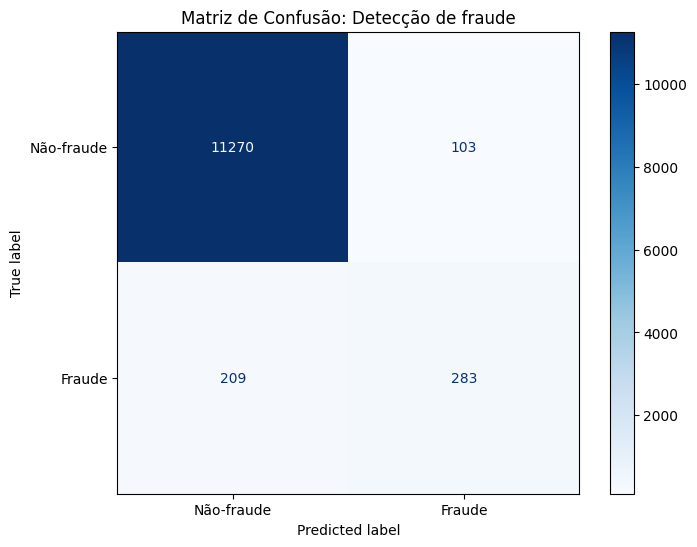

In [ ]:
# Relatório de Classificação
print("--- Relatório de Classificação ---")
print(classification_report(y_teste, y_pred, target_names=['Não-fraude', 'Fraude']))

# Matriz de Confusão Visual
print("--- Matriz de Confusão ---")
cm = confusion_matrix(y_teste, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não-fraude', 'Fraude'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusão: Detecção de fraude')
plt.grid(False) # Remove linhas de grade que podem atrapalhar a visão
plt.show()

#Teste 2: One-Class Support Vector Machine
Treinamento do modelo definitivo.

In [ ]:
from sklearn.svm import OneClassSVM

# Declaração do modelo
modelo_svm1 = OneClassSVM(
                          kernel='rbf',       # Cria as curvas, pode-se testar várias opções
                          gamma='scale',      # Ajuste ao ponto
                          tol=0.001,          # Tolerância ao parar de melhorar
                          nu=0.01,            # Permitividade de erros
                          shrinking=False,
                          max_iter=-1)        # Quantidade máxima de iterações

In [ ]:
# 2. Treinando o modelo
modelo_svm1.fit(X_treino_tratado)

OneClassSVM(nu=0.01, shrinking=False)

In [ ]:
y_pred_raw_svm1 = modelo_svm1.predict(X_teste_tratado)
y_pred_svm1 = [1 if x == -1 else 0 for x in y_pred_raw_svm1]

# `Avaliação do modelo`

--- Relatório de Classificação ---
              precision    recall  f1-score   support

  Não-fraude       0.99      0.98      0.99     11373
      Fraude       0.64      0.80      0.71       492

    accuracy                           0.97     11865
   macro avg       0.81      0.89      0.85     11865
weighted avg       0.98      0.97      0.97     11865



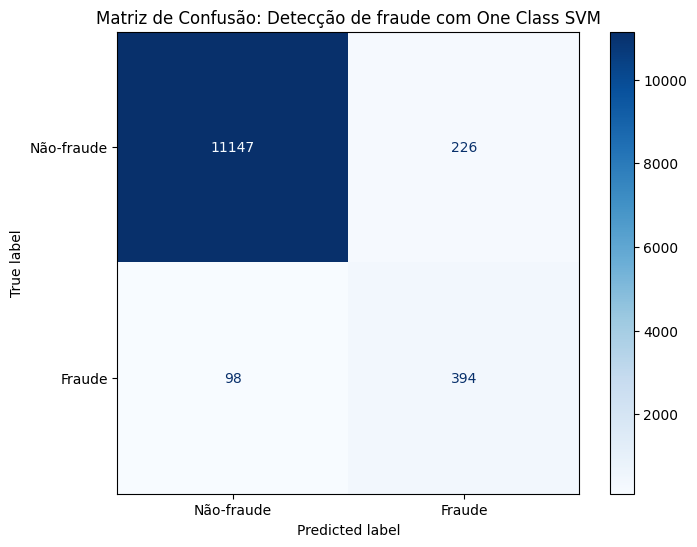

In [ ]:
# Relatório de Classificação
print("--- Relatório de Classificação ---")
print(classification_report(y_teste, y_pred_svm1, target_names=['Não-fraude', 'Fraude']))

# Matriz de Confusão Visual
cm = confusion_matrix(y_teste, y_pred_svm1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não-fraude', 'Fraude'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusão: Detecção de fraude com One Class SVM')
plt.grid(False)
plt.show()

Nosso modelo detectou 80% (recall) das fraudes reais, mesmo sendo treinado apenas com a classe “não-fraude”. Além disso, das transações classificadas como fraude, 64% (precision) realmente eram fraudes, apresentando uma quantidade moderada de alarmes falsos (36%). O F1-score de 71% confirma que o modelo conseguiu detectar muitas fraudes sem gerar excesso de falsos positivos.

In [ ]:
scores = modelo_svm1.decision_function(X_teste_tratado)

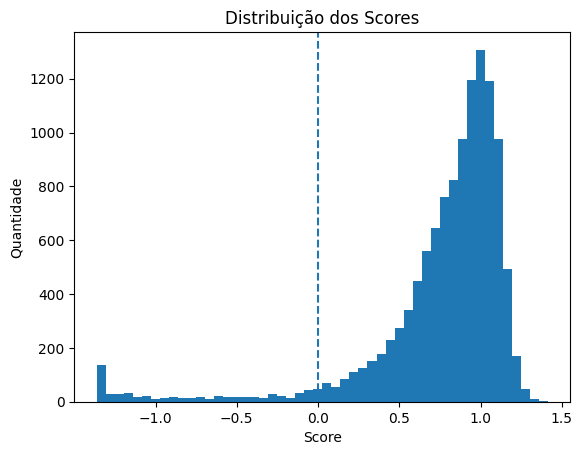

In [ ]:
plt.hist(scores, bins=50)

plt.axvline(0, linestyle='--')

plt.xlabel("Score")
plt.ylabel("Quantidade")
plt.title("Distribuição dos Scores")

plt.show()

O histograma dos scores de anomalia mostra que grande parte dos dados possui valores positivos e próximos de 1, indicando que a maioria das transações aparenta ser normal (“não-fraude”). Contudo, existe uma pequena quantidade de valores negativos, poucos e dispersos, que representam anomalias (possíveis fraudes). Há também pontos próximos de zero, que representam regiões de incerteza do modelo, ocasionando falsos positivos e falsos negativos. Por fim, como existe uma separação razoável no histograma, sem muitas sobreposições próximas ao ponto zero, isso indica que o modelo apresentou capacidade satisfatória de separação entre padrões normais e anômalos.

In [ ]:
precision, recall, thresholds = precision_recall_curve( y_teste, -scores)

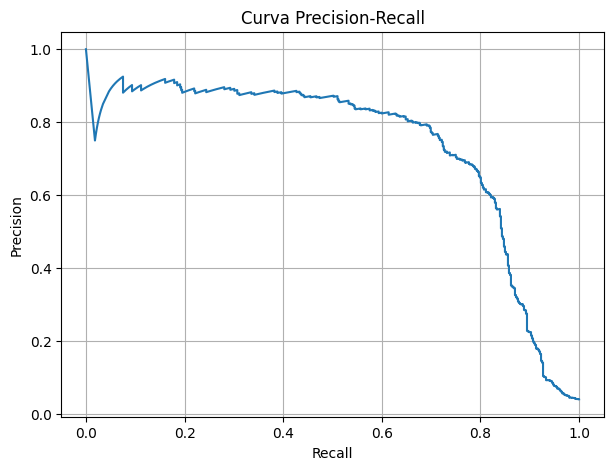

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")

plt.grid(True)

plt.show()

A Curva Precision-Recall inicia com valores elevados de precision e se mantém relativamente estável mesmo com o aumento da sensibilidade (recall), apresentando queda acentuada apenas quando o recall se aproxima de 1. Isso demonstra um comportamento saudável da curva, mantendo boa precisão até valores significativamente altos de recall antes de decair rapidamente.

In [ ]:
ap = average_precision_score(y_teste, -scores)

print("Average Precision:", ap)

Average Precision: 0.7323043914307624


A área sob a Curva PR confirma a boa capacidade do modelo em manter equilíbrio entre precisão e sensibilidade, atingindo um valor de 0,73.



---



`CONCLUSÃO`

O desafio proposto foi desenvolver um modelo para classificação de fraudes bancárias, porém treinando apenas com a classe “não-fraude”. Inicialmente, utilizamos um dataset contendo as duas classes (“fraude” e "não fraude"). A partir disso, realizamos o tratamento do dataset: removemos algumas colunas desnecessárias, separamos as classes, reduzimos a quantidade de instâncias de “não-fraude” devido ao grande volume de dados e, por fim, dividimos o conjunto em treino — utilizando apenas a classe “não-fraude” — e teste, contendo as duas classes embaralhadas. Antes do treinamento, aplicamos a técnica de scaling utilizando o RobustScaler, com o objetivo de reduzir o impacto dos outliers nos dados.

Foram testados dois modelos para o desafio: Isolation Forest e One-Class Support Vector Machine. O primeiro modelo não apresentou resultados satisfatórios, então decidimos focar no One-Class SVM.

Como o modelo escolhido não retorna diretamente “isso é fraude” ou “isso é não-fraude”, mas sim um score de anomalia, não utilizamos apenas a acurácia como métrica principal de avaliação, pois isso poderia levar a falsas conclusões em um cenário altamente desbalanceado. Dessa forma, focamos principalmente na precisão (proporção das transações classificadas como fraude que realmente eram fraude) e na sensibilidade/recall (capacidade do modelo em encontrar as fraudes existentes). Para a avaliação do modelo, utilizamos: scores de anomalia, Curva Precision-Recall e área sob a Curva PR.

Portanto, a avaliação da proposta indicou que o One-Class SVM foi capaz de aprender o comportamento das transações bancárias e identificar padrões de anomalia, atingindo recall de 80% para a classe fraude, o que demonstra elevada capacidade de detecção de eventos fraudulentos, embora ainda apresente presença moderada de falsos positivos (precision de 64%). Além disso, a área sob a curva Precision-Recall de 0,73 sugere desempenho satisfatório em um cenário altamente desbalanceado.